# Tracking clouds, example 1

1. [Input Data](#1.-Input-Data)
2. [Feature Detection](#2.-Feature-Detection)
3. [Tracking / Trajectory Linking](#3.-Trajectory-Linking)
4. [Segmentation](#4.-Segmentation)

## Import Libraries

In [10]:
print("Toy problem:")

Toy problem:


In [1]:
import tobac
import imageio
import os
print('using tobac version', str(tobac.__version__))
import tobac.testing
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_context("talk")

using tobac version 1.6.1


## 1. Input Data

In [2]:
folder = "./to_test_toy_problem/"
image_files = ([os.path.join(folder, f) for f in os.listdir(folder)
                      if f.lower().endswith((".png", ".jpg", ".jpeg"))])
images_no=len(image_files)

we sort the images (by date), print them and extract the data of the recording from the title

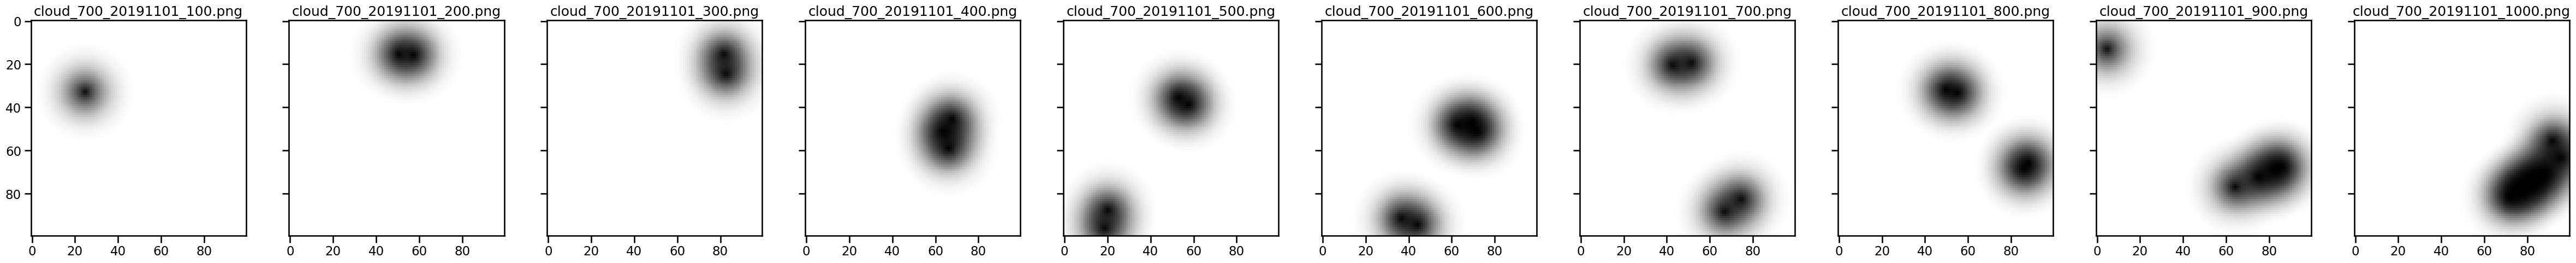

In [3]:
import re

def extract_keys(filename):
    # match pattern like cloud_200_YYYYMMDD_HHMM.png
    m = re.search(r'_(\d{8})_(\d+)\.png$', filename)
    if m:
        date = int(m.group(1))
        num = int(m.group(2))
        return (date, num)
    else:
        return (0, 0)

image_files = sorted(image_files, key=extract_keys)


fig, axs = plt.subplots(ncols=images_no, nrows=1, figsize=(6*images_no, 6), sharey=True)
plt.subplots_adjust(hspace=20)
frames = [imageio.v2.imread(f) for f in image_files]
for i, itime in enumerate(range(0,images_no)):
    img = imageio.v2.imread(image_files[itime])
    axs[i].imshow(img)
    axs[i].set_title(os.path.basename(image_files[itime]))


plt.show()

In [4]:
#generate datatimes from images

import pandas as pd
datetimes = []
for f in image_files:
    basename = os.path.basename(f)
    # Example: "cloud_123_20251008_1200.png"
    # Split by underscore and take the last two parts
    parts = basename.split("_")
    date_str = parts[-2]      # YYYYMMDD
    hour_str = parts[-1].split(".")[0]  # HHHH
    dt_str = date_str + hour_str        # "YYYYMMDDHHHH"
    
    # Convert to pandas datetime
    dt = pd.to_datetime(dt_str, format="%Y%m%d%H%M")  # assuming HHHH is HHMM
    datetimes.append(dt)

# Convert to array
datetimes = pd.to_datetime(datetimes)

#recreate test_data
import numpy as np
import xarray as xr
import imageio as images
#Convert frames to grayscale
frames_gray = [np.mean(f[:, :, :3], axis=2) if f.ndim==3 else f for f in frames]

# Stack into 3D array (time, y, x)
data = np.stack(frames_gray)
n_time, n_y, n_x = data.shape

# Spatial coordinates (example: 1 pixel = 1000 m)
dx = dy = 3000  # adjust to your case
x = np.arange(n_x) * dx
y = -np.arange(n_y) * dy

#Create xarray.DataArray
test_data = xr.DataArray(
    data,
    dims=("time", "y", "x"),
    coords={
        "time": datetimes,
        "y": y,
        "x": x
    },
    name="w",
    attrs={"units": "m s-1"}
)

#Optional: latitude / longitude (linear approximation)
lat_min, lat_max = 40.0, 45.0
lon_min, lon_max = -5.0, 0.0
lat = np.linspace(lat_min, lat_max, n_y)
lon = np.linspace(lon_min, lon_max, n_x)
latitude = np.tile(lat[:, np.newaxis], (1, n_x))
longitude = np.tile(lon[np.newaxis, :], (n_y, 1))
test_data = test_data.assign_coords(latitude=(("y","x"), latitude),
                                    longitude=(("y","x"), longitude))




## 2. Feature Detection

get the tracking parameters (distance and time distances)

In [5]:
dxy, dt = tobac.get_spacings(test_data,grid_spacing=(1, 1))

/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/iris/common/mixin.py:195: FutureWarning: You are using legacy date precision for Iris units - max precision is seconds. In future, Iris will use microsecond precision - available since cf-units version 3.3 - which may affect core behaviour. To opt-in to the new behaviour, set `iris.FUTURE.date_microseconds = True`.
  warnings.warn(message, category=FutureWarning)


the actual detection, we perform the detection (and subsequent steps) on a smoothed version of the data

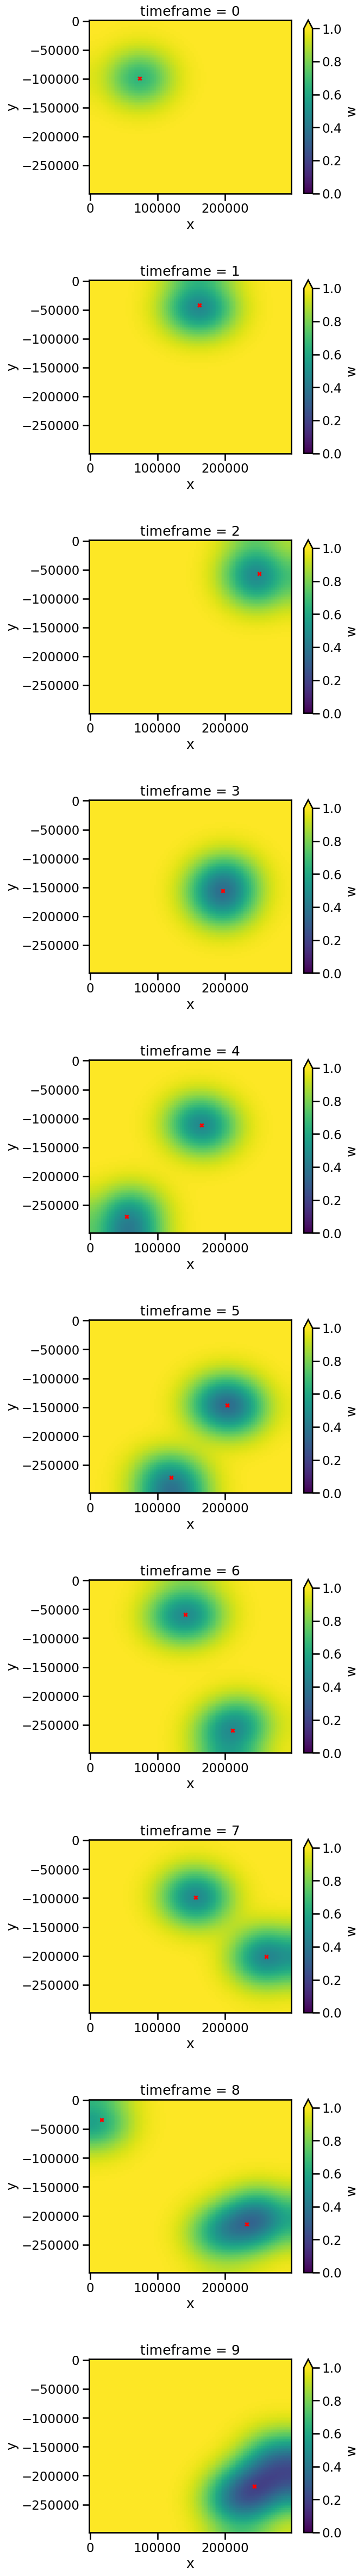

In [6]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import tobac

# === GLOBAL NORMALIZATION ===
vmin = float(test_data.min())
vmax = float(test_data.max())
test_data_norm = (test_data - vmin) / (vmax - vmin)

# === PARAMETERS ===
smooth = 8

# Convert original threshold (155) to normalized [0, 1] scale
norm_threshold = 0.75


# === FEATURE DETECTION ===
features = tobac.feature_detection_multithreshold(
    test_data_norm,
    threshold=[norm_threshold],  # single threshold in normalized space
    dxy=dxy,
    target="minimum",
    position_threshold="center",
    sigma_threshold=smooth
)

# === PLOTTING ===
fig, axs = plt.subplots(ncols=1, nrows=images_no, figsize=(6, 6*images_no), sharey=True)
plt.subplots_adjust(hspace=0.5)

for i, itime in enumerate(range(0, images_no)):
    smoothed_frame = ndimage.gaussian_filter(test_data_norm.isel(time=itime).values, sigma=smooth)
    #smoothed_frame =test_data_norm.isel(time=itime).values
    temp_da = test_data_norm.isel(time=itime).copy()
    temp_da.data = smoothed_frame

    # consistent color range across all frames
    temp_da.plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis")

    # overlay detections
    f = features[features["frame"] == itime]
    f.plot.scatter(
        x="x",
        y="y",
        s=20,
        ax=axs[i],
        color="red",
        marker="x",
    )

    axs[i].set_title(f"timeframe = {itime}")

plt.show()


## 3. Trajectory Linking

Track the movements, each image is taken 1h apart, so 3600 sec, and dxy, tells the spatial dimention of a pixel

Frame 9: 1 trajectories present.


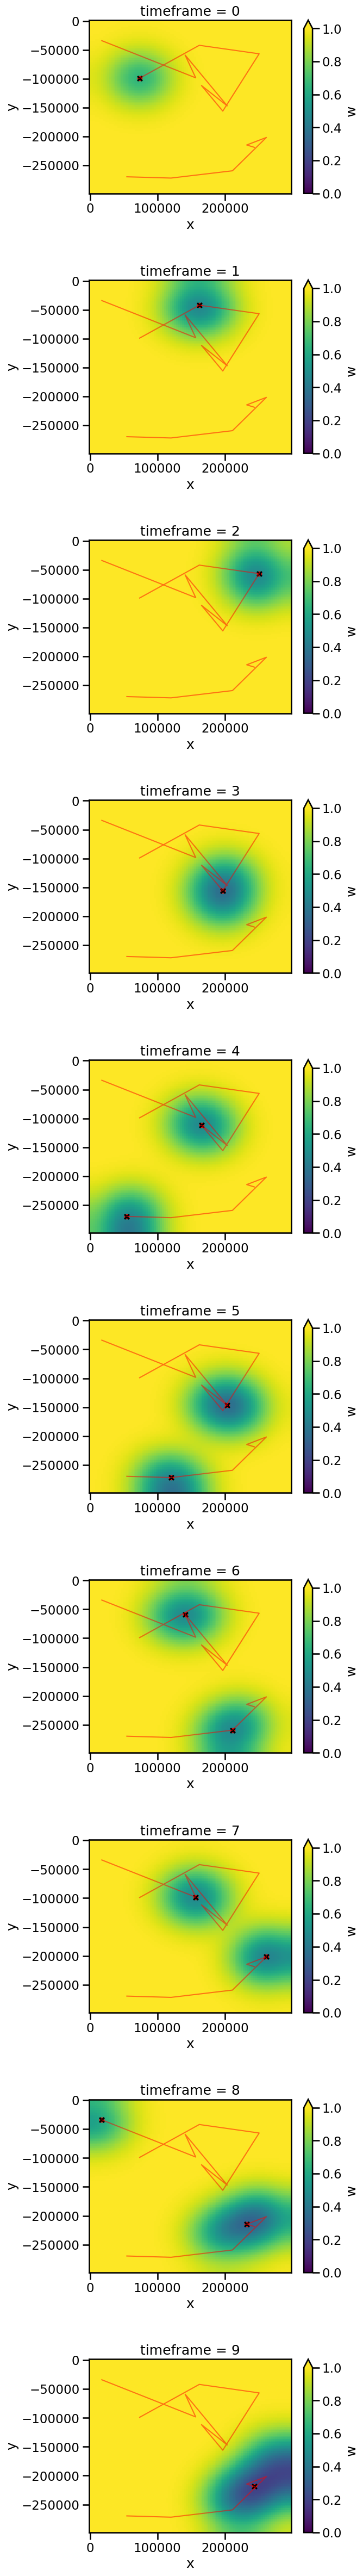

In [7]:

trajectories = tobac.linking_trackpy(features, test_data_norm, dt=3600, dxy=3000, v_max=50)

fig, axs = plt.subplots(ncols=1, nrows=images_no, figsize=(6, 6*images_no), sharey=True)
plt.subplots_adjust(hspace=0.5)
# fig.tight_layout()

cell_ids = trajectories["cell"].dropna().unique()

for i, itime in enumerate(range(0, images_no)):
    # plot the 2D blob field in colors
    
    smoothed_frame = ndimage.gaussian_filter(test_data_norm.isel(time=itime).values, sigma=smooth)
    #smoothed_frame =test_data_norm.isel(time=itime).values
    
    temp_da = test_data_norm.isel(time=itime).copy()
    temp_da.data = smoothed_frame

    # consistent color range across all frames
    temp_da.plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis")
    

    for cell_id in cell_ids:
        track = trajectories[trajectories["cell"] == cell_id]
        track_in_frame = track[track["frame"] == itime]

        # scatter current position
        axs[i].scatter(
            track_in_frame["x"],
            track_in_frame["y"],
            color="red",
            marker="o",
            s=30,
            alpha=0.8,
        )

        # draw a line between consecutive positions (sorted by time)
        axs[i].plot(
            track["x"],
            track["y"],
            color="red",
            linewidth=1.5,
            alpha=0.5,
        )

    # plot the detected feature as black cross
    f = features[features["frame"] == itime]
    f.plot.scatter(
        x="x",
        y="y",
        s=40,
        ax=axs[i],
        color="black",
        marker="x",
    )

    axs[i].set_title(f"timeframe = {itime}")

## 4. Segmentation

In [8]:
segments_all = []

for itime in range(len(test_data.time)):
    print(f"Segmenting frame {itime} ...")
    print(f"Segmenting frame {itime}...")
    
    # --- SMOOTHING ---
    smoothed_frame = ndimage.gaussian_filter(
        test_data_norm.isel(time=itime).values, sigma=smooth
    )
    
    # Create a DataArray with the smoothed data but keep coordinates and attrs
    temp_da = test_data_norm.isel(time=[itime]).copy()
    temp_da.data = smoothed_frame[np.newaxis, ...]  # keep time dim
    
    field_2d = temp_da

    f = features[features["frame"] == itime]  # features in this frame
    
    if f.empty:
        print(f"No features found for frame {itime}, skipping segmentation.")
        segments_all.append((itime, None, None))
        continue

    # perform segmentation
    segment_labels, segments = tobac.segmentation_2D(
        f,
        field_2d,
        dxy=dxy,
        threshold=norm_threshold,
        target="minimum"
        
    )

    # store results
    segments_all.append((itime, segment_labels, segments))


Segmenting frame 0 ...
Segmenting frame 0...
Segmenting frame 1 ...
Segmenting frame 1...
Segmenting frame 2 ...
Segmenting frame 2...
Segmenting frame 3 ...
Segmenting frame 3...
Segmenting frame 4 ...
Segmenting frame 4...
Segmenting frame 5 ...
Segmenting frame 5...
Segmenting frame 6 ...
Segmenting frame 6...
Segmenting frame 7 ...
Segmenting frame 7...
Segmenting frame 8 ...
Segmenting frame 8...
Segmenting frame 9 ...
Segmenting frame 9...


/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: UserWarning: As of v1.6.0, segmentation with time length 1 will return time as a coordinate instead of dropping it (i.e., output will now be 1xMxN instead of MxN). 
  warnings.warn(
/home/enry/miniconda3/envs/tobac/lib/python3.10/site-packages/tobac/segmentation/watershed_segmentation.py:1264: Us

As the name implies, the first object returned is an array in which the segmented areas belonging to each feature have the same label value as that feature. The second output is a dataframe of the detected features updated with information about their segmented regions (currently only the number of pixels segmented)

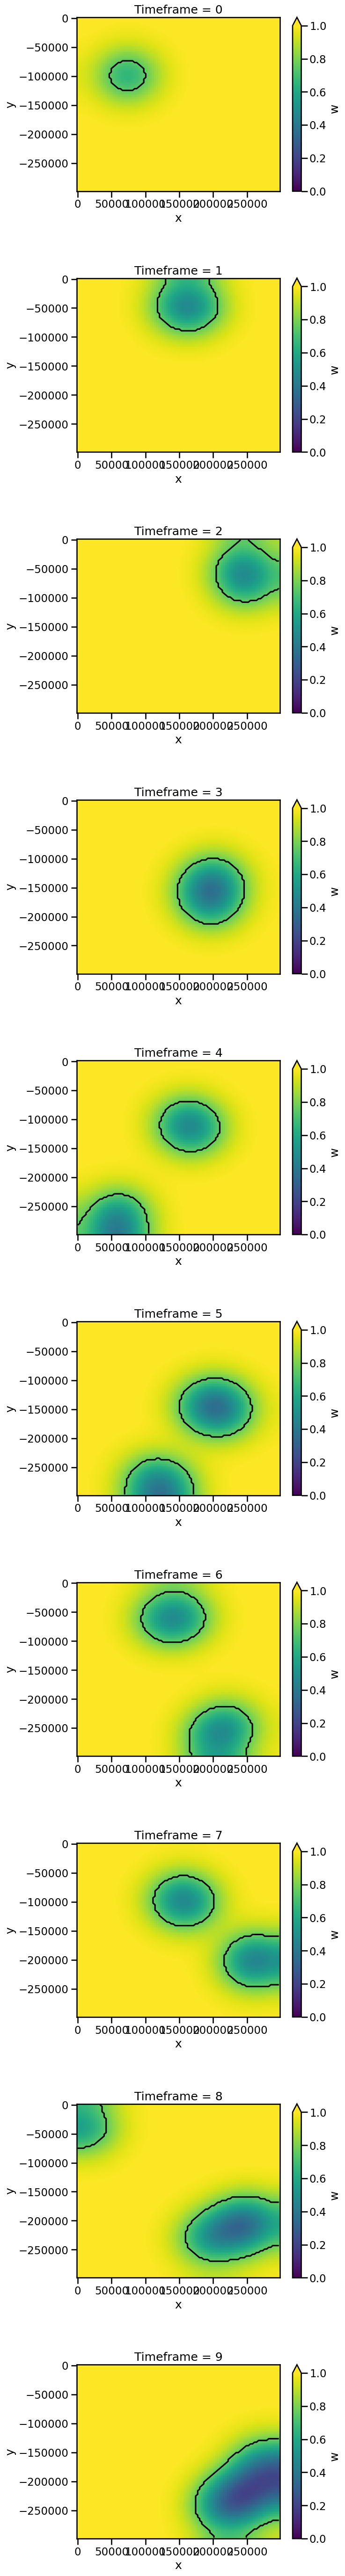

In [9]:
import matplotlib.pyplot as plt

# Select the frames you want to plot
plot_frames = range(0, images_no)

fig, axs = plt.subplots(ncols=1, nrows=len(plot_frames), figsize=(7, 7*len(plot_frames)), sharey=True)
plt.subplots_adjust(hspace=0.5)

for i, itime in enumerate(plot_frames):
    # Get the field for this frame
    
    smoothed_frame = ndimage.gaussian_filter(test_data_norm.isel(time=itime).values, sigma=smooth)

    temp_da = test_data_norm.isel(time=itime).copy()
    temp_da.data = smoothed_frame

    # consistent color range across all frames
    temp_da.plot(ax=axs[i], vmin=0, vmax=1, cmap="viridis")
    
    # Extract segmentation for this frame from segments_all
    # We find the entry with matching time
    entry = next((s for s in segments_all if s[0] == itime), None)
    
    if entry is not None:
        
        _, seg_labels, _ = entry
        if seg_labels is not None:
            # seg_labels may have a single-element time dimension
            seg_labels2d = seg_labels.isel(time=0)  # drop the time dim for contour
            # Only plot contour if there are actual segmented pixels
            seg_labels2d.plot.contour(levels=[0.5], ax=axs[i], colors="k")
        

    axs[i].set_title(f"Timeframe = {itime}")
    
plt.show()
